In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("dataset.csv")

In [3]:
df.head()

,user,text,likes,comments,shares,timestamp
0,alice,Terrible support!!!,10.0,NaN,NaN,2024-01-5
1,eva,Not worth it...,30.0,5.0,1.0,2024-01-1
2,frank,Worst experience ever...,50.0,1.0,0.0,2024-01-8
3,david,NaN,30.0,NaN,NaN,2024-01-10
4,bob,Just okay...,50.0,2.0,0.0,2024-01-4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   user       50 non-null     object 
 1   text       48 non-null     object 
 2   likes      40 non-null     float64
 3   comments   34 non-null     float64
 4   shares     37 non-null     float64
 5   timestamp  50 non-null     object 
dtypes: float64(3), object(3)
memory usage: 2.5+ KB


In [5]:
df.isnull().sum()

user          0
text          2
likes        10
comments     16
shares       13
timestamp     0
dtype: int64

In [6]:
df['likes'].fillna(0,inplace=True)
df['comments'].fillna(0,inplace=True)
df['shares'].fillna(0,inplace=True)

df['text'].fillna("",inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_23532\2469763372.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['likes'].fillna(0,inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_23532\2469763372.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doi

In [7]:
import re

df['text']=df['text'].str.strip().str.lower()
df['text']=df['text'].apply(lambda x: re.sub(r"http\S+|[^a-zA-Z ]","",x))

In [8]:
df['likes'] = df['likes'].astype(int)
df['comments'] = df['comments'].astype(int)
df['shares'] = df['shares'].astype(int)

In [9]:
df['engagement']=df['likes']+df['comments']+df['shares']

In [10]:
user_engagement=df.groupby('user')['engagement'].sum().sort_values(ascending=False)
print(user_engagement)

user
frank      322
david      233
charlie    227
alice      222
bob        147
eva        101
Name: engagement, dtype: int64


In [12]:
top_posts=df.sort_values(by='engagement',ascending=False)
print(top_posts[['text','engagement']].head())

                     text  engagement
40       terrible support          55
36  amazing service happy          53
9         check this out           52
38        check this out           52
4               just okay          52


<Axes: xlabel='user'>

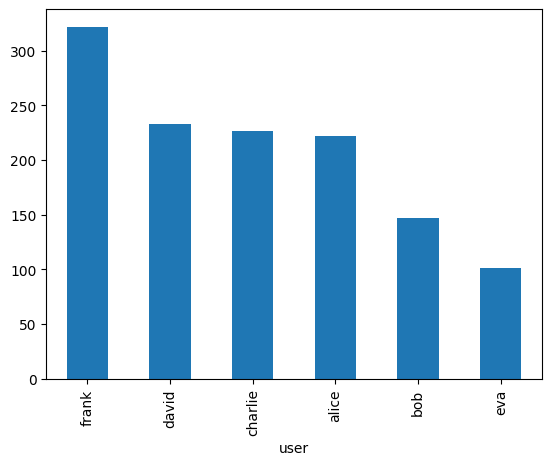

In [13]:
user_engagement.plot(kind='bar')

<Axes: xlabel='engagement', ylabel='Count'>

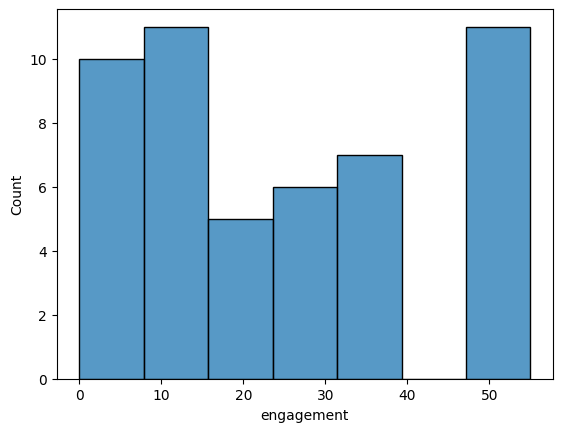

In [15]:
import seaborn as sns
sns.histplot(df['engagement'])

NameError: name 'plt' is not defined

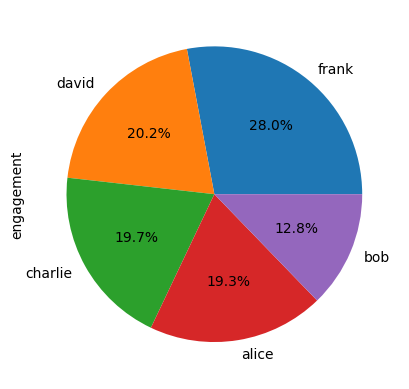

In [16]:
user_engagement.head(5).plot(kind='pie', autopct='%1.1f%%')
plt.title("Top Users Share")
plt.ylabel("")
plt.show()

NameError: name 'plt' is not defined

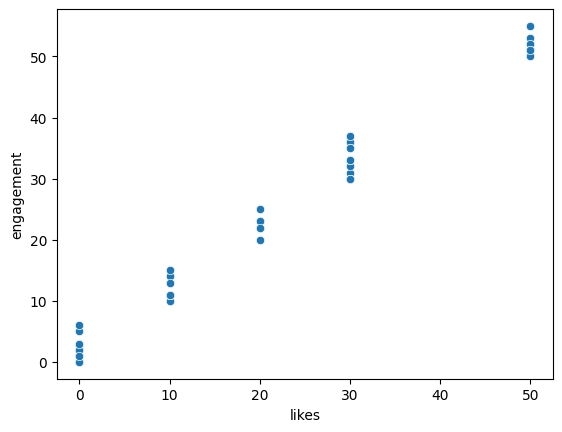

In [17]:
sns.scatterplot(x=df['likes'], y=df['engagement'])
plt.title("Likes vs Engagement")
plt.show()